Data Preprocessing

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
from sklearn.naive_bayes import GaussianNB
#from tensorflow.keras.utils import to_categorical

In [11]:
# Reading in the datasets
additional_test = pd.read_csv('test/Features/additional_features.csv')
color_test = pd.read_csv('test/Features/color_histogram.csv')
hog_test = pd.read_csv('test/Features/hog_pca.csv')
testing = pd.read_csv('test/test_metadata.csv')

additional_train = pd.read_csv('train/Features/additional_features.csv')
color_train = pd.read_csv('train/Features/color_histogram.csv')
hog_train = pd.read_csv('train/Features/hog_pca.csv')
training = pd.read_csv('train/train_metadata.csv')


# PREPROCESSING THE DATA

# Standardising additional_features 
additional_features_columns = ['edge_density', 'mean_b', 'mean_g', 'mean_r']
scaler_additional = StandardScaler()
additional_train[additional_features_columns] = scaler_additional.fit_transform(additional_train[additional_features_columns])
additional_test[additional_features_columns] = scaler_additional.transform(additional_test[additional_features_columns])

# Standardising color histograms
color_columns = [col for col in color_train.columns if col.startswith("ch_")]
scaler_color = StandardScaler()
color_train[color_columns] = scaler_color.fit_transform(color_train[color_columns])
color_test[color_columns] = scaler_color.transform(color_test[color_columns])

# Once preprocessed, we can now merge the features together for the training metadata set
combined_training = pd.merge(training, additional_train, on='image_path')
combined_training = pd.merge(combined_training, color_train, on='image_path')
combined_training = pd.merge(combined_training, hog_train, on='image_path')
combined_training = combined_training[[col for col in combined_training.columns if col != 'ClassId'] + ['ClassId']]

# Same for the testing metadata set
combined_testing = pd.merge(testing, additional_test, on='image_path')
combined_testing = pd.merge(combined_testing, color_test, on='image_path')  
combined_testing = pd.merge(combined_testing, hog_test, on='image_path')
combined_testing = combined_testing[[col for col in combined_testing.columns if col != 'ClassId'] + ['ClassId']]


# FEATURE SELECTION via Mutual Information
def apply_mutual_info_filtering(combined_training, top_k=50):
    X = combined_training.drop(columns=['id', 'image_path', 'ClassId'])
    y = combined_training['ClassId']
    
    mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)
    mi_df = pd.DataFrame({'feature': X.columns, 'mutual_info': mi_scores})
    mi_df_sorted = mi_df.sort_values(by='mutual_info', ascending=False)
    top_features = mi_df_sorted.head(top_k)['feature'].tolist()
    
    return combined_training[top_features + ['ClassId']], mi_df_sorted


print("Applying Mutual Information Filtering to Training Data:")
training_filtered, mi_df_train_sorted = apply_mutual_info_filtering(combined_training, top_k=50)
print("Top 50 Features based on Mutual Information:")

testing_filtered = combined_testing[training_filtered.columns.tolist()]


Applying Mutual Information Filtering to Training Data:
Top 50 Features based on Mutual Information:


Best KNN Model Accuracy on Additional Features: 0.2832 with parameters: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.26      0.31      0.28        62
           2       0.27      0.24      0.25        63
           3       0.22      0.26      0.24        39
           4       0.27      0.33      0.30        55
           5       0.29      0.25      0.27        52
           6       0.50      0.58      0.54        12
           7       0.28      0.33      0.30        40
           8       0.35      0.41      0.38        39
           9       0.16      0.17      0.17        41
          10       0.30      0.32      0.31        56
          11       0.10      0.08      0.09        37
          12       0.36      0.31      0.33        59
          13       0.33      0.33      0.33        60
          14       0.24      0.27      0.26        22

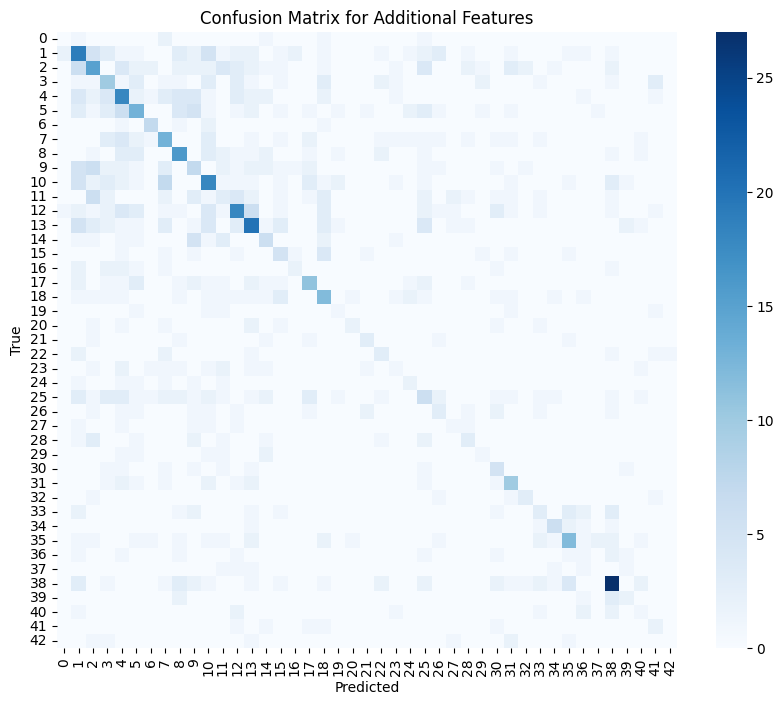

C:\Users\asus\AppData\Local\Temp\ipykernel_21624\1756340236.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=combined_additional, x='ClassId', palette='viridis')


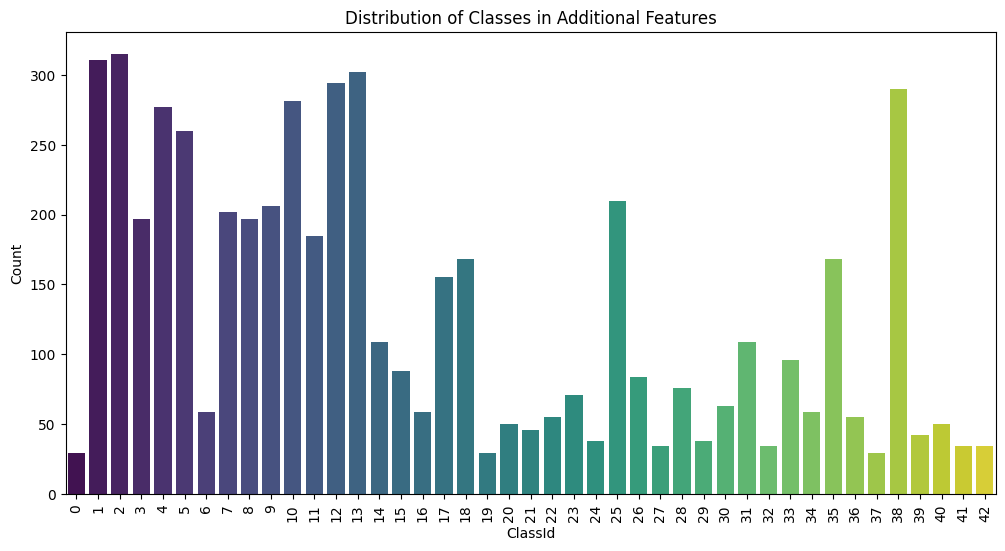

In [12]:
# run on additional features
additional_train = pd.read_csv('train/Features/additional_features.csv')

additional_features_columns = ['edge_density', 'mean_b', 'mean_g', 'mean_r']
scaler = StandardScaler()
additional_train[additional_features_columns] = scaler.fit_transform(additional_train[additional_features_columns])


training = pd.read_csv('train/train_metadata.csv')
# Merge additional features with training metadata
combined_additional = pd.merge(training, additional_train, on='image_path')
combined_additional = combined_additional.drop(columns=['id', 'image_path'])

X_additional = combined_additional.drop(columns=['ClassId']).values
Y_additional = combined_additional['ClassId'].values

# Split the data into training and validation sets
X_train_additional, X_val_additional, Y_train_additional, Y_val_additional = train_test_split(
    X_additional, Y_additional, test_size=0.2, random_state=123, stratify=Y_additional
)

# KNN on additional features
from sklearn.model_selection import GridSearchCV
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_additional, Y_train_additional)
best_knn = grid_search.best_estimator_

# Evaluate the best KNN model on the validation set
Y_val_pred_additional = best_knn.predict(X_val_additional)
accuracy_additional = accuracy_score(Y_val_additional, Y_val_pred_additional)
print(f"Best KNN Model Accuracy on Additional Features: {accuracy_additional:.4f}", "with parameters:", grid_search.best_params_)
# Classification report for additional features
print(classification_report(Y_val_additional, Y_val_pred_additional))
# Confusion matrix for additional features
conf_matrix_additional = confusion_matrix(Y_val_additional, Y_val_pred_additional)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_additional, annot=False, cmap='Blues', fmt='g')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Additional Features")
plt.show()

# show distribution of classes in additional features
plt.figure(figsize=(12, 6))
sns.countplot(data=combined_additional, x='ClassId', palette='viridis')
plt.title('Distribution of Classes in Additional Features')
plt.xlabel('ClassId')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()




Best KNN Model Accuracy on HOG PCA Features: 0.7668 with parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       0.50      0.17      0.25         6
           1       0.74      0.63      0.68        62
           2       0.54      0.68      0.60        63
           3       0.51      0.54      0.53        39
           4       0.60      0.64      0.62        55
           5       0.65      0.62      0.63        52
           6       0.91      0.83      0.87        12
           7       0.61      0.68      0.64        40
           8       0.70      0.79      0.75        39
           9       0.81      0.95      0.88        41
          10       0.90      0.82      0.86        56
          11       0.54      0.70      0.61        37
          12       1.00      0.98      0.99        59
          13       1.00      1.00      1.00        60
          14       1.00      0.82      0.90        22
 

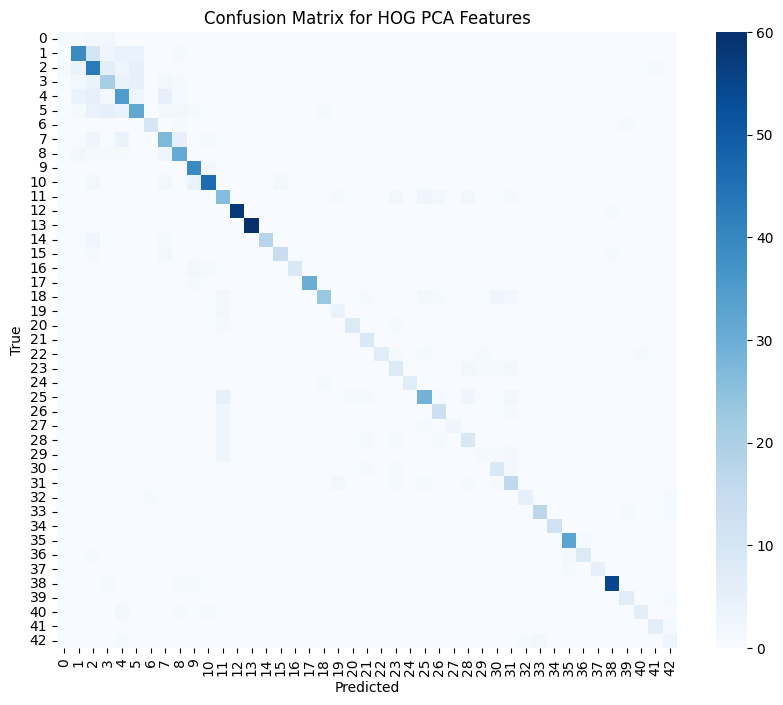

In [22]:
# run knn on hog pca features
hog_train = pd.read_csv('train/Features/hog_pca.csv')
hog_columns = [col for col in hog_train.columns if col != 'image_path']
scaler = StandardScaler()
hog_train[hog_columns] = scaler.fit_transform(hog_train[hog_columns])

training = pd.read_csv('train/train_metadata.csv')
# Merge HOG PCA features with training metadata
combined_hog = pd.merge(training, hog_train, on='image_path')

combined_hog = combined_hog.drop(columns=['id', 'image_path'])
X_hog = combined_hog.drop(columns=['ClassId']).values
Y_hog = combined_hog['ClassId'].values
# Split the data into training and validation sets
X_train_hog, X_val_hog, Y_train_hog, Y_val_hog = train_test_split(
    X_hog, Y_hog, test_size=0.2, random_state=123, stratify=Y_hog
)

# KNN on HOG PCA features
knn_hog = KNeighborsClassifier()
param_grid_hog = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search_hog = GridSearchCV(knn_hog, param_grid_hog, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_hog.fit(X_train_hog, Y_train_hog)
best_knn_hog = grid_search_hog.best_estimator_
# Evaluate the best KNN model on the validation set
Y_val_pred_hog = best_knn_hog.predict(X_val_hog)
accuracy_hog = accuracy_score(Y_val_hog, Y_val_pred_hog)
print(f"Best KNN Model Accuracy on HOG PCA Features: {accuracy_hog:.4f}", "with parameters:", grid_search_hog.best_params_)
# Classification report for HOG PCA features
print(classification_report(Y_val_hog, Y_val_pred_hog))
# Confusion matrix for HOG PCA features
conf_matrix_hog = confusion_matrix(Y_val_hog, Y_val_pred_hog)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_hog, annot=False, cmap='Blues', fmt='g')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for HOG PCA Features")
plt.show()


test_hog = pd.read_csv('test/Features/hog_pca.csv')
X_test = test_hog.drop(columns=['image_path']).values
# Predicting on the test set using the best KNN model for additional features
Y_test_pred_hog = best_knn_hog.predict(X_test)

submission_hog = pd.DataFrame({
    'id': combined_testing['id'].values,
    'ClassId': Y_test_pred_hog
})

submission_hog.to_csv('submission_hog.csv', index=False)

KNN Accuracy with k=1: 0.6913


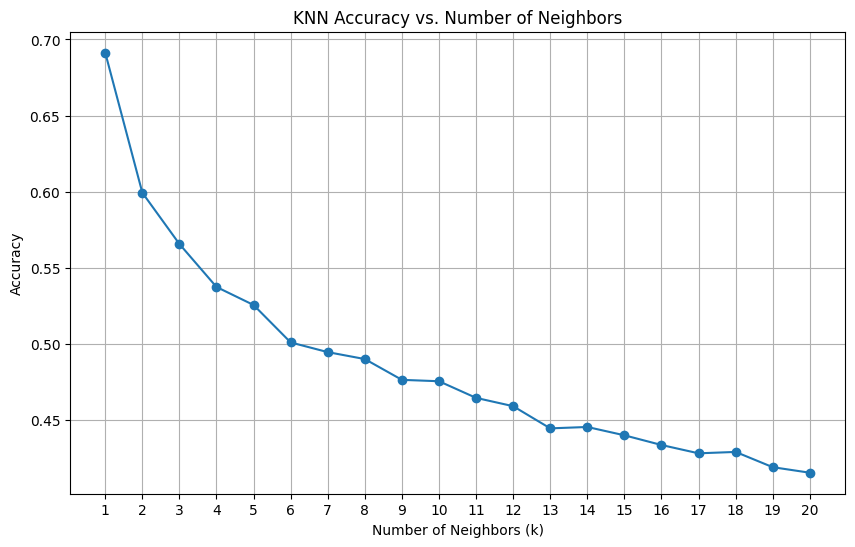

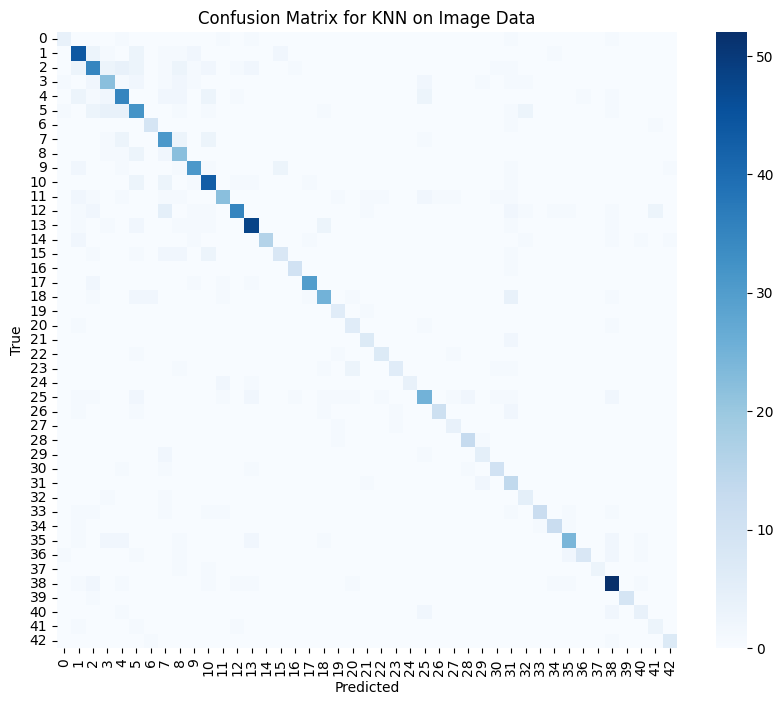

              precision    recall  f1-score   support

           0       0.57      0.44      0.50         9
           1       0.67      0.76      0.71        58
           2       0.62      0.57      0.60        61
           3       0.58      0.59      0.59        37
           4       0.62      0.65      0.64        54
           5       0.56      0.62      0.59        52
           6       0.75      0.82      0.78        11
           7       0.57      0.74      0.65        42
           8       0.51      0.76      0.61        29
           9       0.78      0.76      0.77        41
          10       0.70      0.80      0.75        54
          11       0.76      0.59      0.67        37
          12       0.88      0.64      0.74        55
          13       0.80      0.80      0.80        60
          14       1.00      0.67      0.80        24
          15       0.62      0.44      0.52        18
          16       0.83      0.91      0.87        11
          17       0.91    

In [14]:
import pandas as pd
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Parameters
image_size = (32, 32)
image_dir = 'train/Images'
metadata_path = 'train/train_metadata.csv'

# Load metadata
metadata = pd.read_csv(metadata_path)

# Load and preprocess images
def load_images_from_metadata(metadata, image_dir, image_size=(32, 32)):
    X, y = [], []
    for _, row in metadata.iterrows():
        filename = row['image_path']
        label = row['ClassId']
        filepath = os.path.join(image_dir, filename)
        img = cv2.imread(filepath)
        if img is not None:
            try:
                img = cv2.resize(img, image_size)
                X.append(img)
                y.append(label)
            except:
                print(f"Skipping image due to resize failure: {filename}")
        else:
            print(f"Failed to load image: {filename}")
    return np.array(X).astype(np.float32), np.array(y)

# Load data
X, y = load_images_from_metadata(metadata, image_dir)
X = X / 255.0  # Normalize pixel values
X = X.reshape(X.shape[0], -1)  # Flatten for KNN

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# visualise accuracy of KNN of k = 1 to k = 20
k_values = np.arange(1, 21)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"KNN Accuracy with k=1: {accuracy_score(y_test, y_pred):.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Accuracy vs. Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid()
plt.show()

# show confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=False, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for KNN on Image Data')
plt.show()

# show accuracy, precision, recall, f1-score
print(classification_report(y_test, y_pred, target_names=[str(i) for i in np.unique(y)]))



Benchmark Model

In [15]:
from sklearn.dummy import DummyClassifier

X_train = np.array(training_filtered.drop(columns=['ClassId']))
Y_train = np.array(training_filtered['ClassId'])

X_train_split, X_val, Y_train_split, Y_val = train_test_split(X_train, Y_train, test_size=0.3, random_state=42)


dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, Y_train)
y_dummy = dummy.predict(X_val)
print("Baseline Accuracy:", accuracy_score(Y_val, y_dummy))

Baseline Accuracy: 0.058287795992714025


Neural Network Model

In [16]:
# NEURAL NETWORK
X_train = np.array(training_filtered.drop(columns=['ClassId']))
Y_train = np.array(training_filtered['ClassId'])

m, n = X_train.shape

shuffled_df = training_filtered.sample(frac=1, random_state=42).reset_index(drop=True)
X_train = shuffled_df.drop(columns=['ClassId']).to_numpy()
Y_train = shuffled_df['ClassId'].to_numpy()
X = X_train.T

numInputs = X.shape[0]
numHidden = 256
numOutput = 43


# Probably a good idea to integrate some form of dropout here
# Necessary functions for the neural network
def init_params():
    W1 = np.random.randn(numHidden, numInputs) * np.sqrt(2. / numInputs)
    b1 = np.zeros((numHidden, 1))
    W2 = np.random.randn(numOutput, numHidden) * np.sqrt(2. / numHidden)
    b2 = np.zeros((numOutput, 1))
    return W1, b1, W2, b2

def forward_propagation(X, W1, b1, W2, b2, dropout_rate=0.5, training=True):
    Z1 = np.dot(W1, X) + b1
    A1 = np.maximum(0, Z1)  # ReLU

    if training:
        # Dropout mask: 1 with probability (1 - dropout_rate), 0 otherwise
        dropout_mask = (np.random.rand(*A1.shape) > dropout_rate).astype(float)
        A1 *= dropout_mask  # Apply mask
        A1 /= (1 - dropout_rate)  # Inverted dropout scaling

    Z2 = np.dot(W2, A1) + b2
    exp_scores = np.exp(Z2 - np.max(Z2, axis=0, keepdims=True))
    A2 = exp_scores / np.sum(exp_scores, axis=0, keepdims=True)
    return A1, A2


def backward_propagation(X, Y, A1, A2, W1, W2):
    m = X.shape[1]
    dZ2 = A2 - Y 
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = np.dot(W2.T, dZ2) * (A1 > 0)
    dW1 = (1 / m) * np.dot(dZ1, X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

def one_hot_encode(Y, num_classes):
    m = Y.shape[0]
    Y_encoded = np.zeros((num_classes, m))
    Y_encoded[Y, np.arange(m)] = 1
    return Y_encoded

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    return W1, b1, W2, b2

def get_accuracy(A2, Y):
    predictions = np.argmax(A2, axis=0)
    accuracy = np.mean(predictions == Y)
    return accuracy*100

def predict(A2):
    return np.argmax(A2, axis=0)

def gradient_descent(X, Y, W1, b1, W2, b2, learning_rate=0.01, epochs=1000, dropout_rate=0.5):
    Y_encoded = one_hot_encode(Y, numOutput)
    for epoch in range(epochs):
        # Apply dropout only during training
        A1, A2 = forward_propagation(X, W1, b1, W2, b2, dropout_rate=dropout_rate, training=True)

        dW1, db1, dW2, db2 = backward_propagation(X, Y_encoded, A1, A2, W1, W2)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)

        if epoch % 100 == 0:
            A1_val, A2_val = forward_propagation(X, W1, b1, W2, b2, training=False)
            log_probs = -np.log(A2_val[Y, np.arange(Y.shape[0])])
            loss = np.mean(log_probs)
            acc = get_accuracy(A2_val, Y)
            print(f"Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {acc:.2f}%")

    return W1, b1, W2, b2


X = X_train.T 
Y = Y_train.astype(int)

W1, b1, W2, b2 = gradient_descent(X, Y, *init_params(), learning_rate=0.1, epochs=1000)


# Confusion Matrix

'''
A1, A2 = forward_propagation(X, W1, b1, W2, b2)
Y_pred = predict(A2)
conf_matrix = confusion_matrix(Y_train, Y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=False, cmap='Blues', fmt='g')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(Y_train, Y_pred))
'''



Epoch 0, Loss: 4.2151, Accuracy: 2.57%
Epoch 100, Loss: 1.7805, Accuracy: 52.08%
Epoch 200, Loss: 1.4454, Accuracy: 60.30%
Epoch 300, Loss: 1.2709, Accuracy: 64.69%
Epoch 400, Loss: 1.1555, Accuracy: 67.77%
Epoch 500, Loss: 1.0703, Accuracy: 70.12%
Epoch 600, Loss: 1.0032, Accuracy: 72.07%
Epoch 700, Loss: 0.9479, Accuracy: 73.34%
Epoch 800, Loss: 0.9017, Accuracy: 74.78%
Epoch 900, Loss: 0.8614, Accuracy: 76.18%


'\nA1, A2 = forward_propagation(X, W1, b1, W2, b2)\nY_pred = predict(A2)\nconf_matrix = confusion_matrix(Y_train, Y_pred)\nplt.figure(figsize=(10, 8))\nsns.heatmap(conf_matrix, annot=False, cmap=\'Blues\', fmt=\'g\')\nplt.xlabel("Predicted")\nplt.ylabel("True")\nplt.title("Confusion Matrix")\nplt.show()\n\nprint(classification_report(Y_train, Y_pred))\n'

In [17]:
# Predicting on the test set
X_test = np.array(testing_filtered.drop(columns=['ClassId']))
X_test_np = X_test.T

_, A2_test = forward_propagation(X_test_np, W1, b1, W2, b2)
predicted_classes = np.argmax(A2_test, axis=0)

NN_output_df = pd.DataFrame({
    'id': combined_testing['id'].values,
    'ClassId': predicted_classes
})

NN_output_df.to_csv('submission.csv', index=False)


Naive Bayes Classification

Naive Bayes Accuracy: 0.33576199149969643
              precision    recall  f1-score   support

           0       0.14      0.43      0.21         7
           1       0.44      0.43      0.43        86
           2       0.34      0.36      0.35        84
           3       0.41      0.24      0.30        58
           4       0.29      0.08      0.13        86
           5       0.24      0.05      0.08        79
           6       0.02      0.86      0.04        14
           7       0.44      0.07      0.12        60
           8       0.10      0.08      0.09        64
           9       0.66      0.43      0.52        68
          10       0.30      0.12      0.17        94
          11       0.33      0.14      0.20        56
          12       1.00      0.76      0.86        79
          13       1.00      0.68      0.81        90
          14       0.93      0.79      0.85        33
          15       0.24      0.48      0.32        25
          16       0.53      0.40      

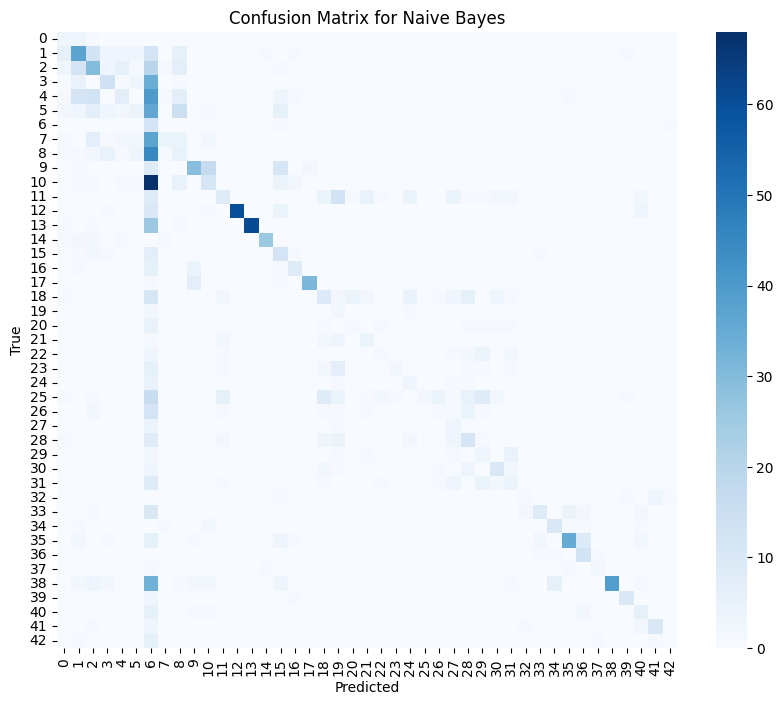

In [18]:
X_train_split, X_val, Y_train_split, Y_val = train_test_split(X_train, Y_train, test_size=0.3, random_state=42)

nb_model = GaussianNB()
nb_model.fit(X_train_split, Y_train_split)

y_pred_nb = nb_model.predict(X_val)

# Evaluating
print("Naive Bayes Accuracy:", accuracy_score(Y_val, y_pred_nb))
print(classification_report(Y_val, y_pred_nb))

# show confusion matrix
conf_matrix_nb = confusion_matrix(Y_val, y_pred_nb)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_nb, annot=False, cmap='Blues', fmt='g')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Naive Bayes")
plt.show()

Ensemble Stacking Model

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

X_train = np.array(training_filtered.drop(columns=['ClassId']))
Y_train = np.array(training_filtered['ClassId'])

X_train_split, X_val, Y_train_split, Y_val = train_test_split(X_train, Y_train, test_size=0.3, random_state=42)

# Level-0 base models
rf = RandomForestClassifier(random_state=1)
lr = LogisticRegression(max_iter=1000)
nb = GaussianNB()

# Train base models on training data
rf.fit(X_train, Y_train)
lr.fit(X_train, Y_train)
nb.fit(X_train, Y_train)

# Predict on validation set
rf_pred = rf.predict(X_val)
lr_pred = lr.predict(X_val)
nb_pred = nb.predict(X_val)

# Stack predictions as features for meta-model
meta_X = np.vstack((rf_pred, lr_pred, nb_pred)).T
meta_y = Y_val

# Level-1 meta-model
meta_model = LogisticRegression()
meta_model.fit(meta_X, meta_y)

# Evaluate the stacked model
meta_val_pred = meta_model.predict(meta_X)
print("Stacked Model Accuracy:", accuracy_score(meta_y, meta_val_pred))


# While uncertain about the performance of this model, we can assume it sucks because of the low accuracy of the base models, namely the Naive Bayes model.

Stacked Model Accuracy: 0.3381906496660595


c:\Users\asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os
import cv2

class ResNet50ImageClassifier:
    def __init__(self, num_classes=None, input_size=(32, 32, 3)):
        self.num_classes = num_classes
        self.input_size = input_size
        self.model = None
        self.label_encoder = LabelEncoder()
        self.class_names = None
        
    def preprocess_image(self, image_path, target_size=(32, 32)):
        """
        Load and preprocess a single image to 32x32 pixels
        """
        try:
            # Load image
            img = load_img(image_path)
            
            # Convert to array
            img_array = img_to_array(img)
            
            # Resize to 32x32
            img_resized = cv2.resize(img_array, target_size)
            
            # Ensure 3 channels (RGB)
            if len(img_resized.shape) == 2:
                img_resized = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)
            elif img_resized.shape[2] == 1:
                img_resized = np.repeat(img_resized, 3, axis=2)
            
            return img_resized
            
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return None
    
    def load_metadata(self, metadata_path):
        """
        Load metadata CSV file and return dataframe
        Expected columns: filename, class (or similar)
        """
        try:
            df = pd.read_csv(metadata_path)
            print(f"Loaded metadata with shape: {df.shape}")
            print(f"Columns: {df.columns.tolist()}")
            print(f"Sample data:")
            print(df.head())
            return df
        except Exception as e:
            print(f"Error loading metadata: {e}")
            return None
    
    def prepare_dataset_from_folder(self, images_folder, metadata_path, 
                                  filename_col='filename', class_col='class'):
        """
        Prepare dataset from folder structure with CSV metadata
        """
        # Load metadata
        df = self.load_metadata(metadata_path)
        if df is None:
            return None, None
        
        # Check if specified columns exist
        if filename_col not in df.columns:
            print(f"Column '{filename_col}' not found. Available columns: {df.columns.tolist()}")
            return None, None
        
        if class_col not in df.columns:
            print(f"Column '{class_col}' not found. Available columns: {df.columns.tolist()}")
            return None, None
        
        # Get unique classes and encode labels
        self.class_names = sorted(df[class_col].unique())
        self.num_classes = len(self.class_names)
        print(f"Found {self.num_classes} unique classes: {self.class_names}")
        
        # Encode labels
        encoded_labels = self.label_encoder.fit_transform(df[class_col])
        
        # Create full image paths
        image_paths = []
        labels = []
        missing_files = []
        
        for idx, row in df.iterrows():
            img_path = os.path.join(images_folder, row[filename_col])
            
            # Check if file exists
            if os.path.exists(img_path):
                image_paths.append(img_path)
                labels.append(encoded_labels[idx])
            else:
                missing_files.append(row[filename_col])
        
        if missing_files:
            print(f"Warning: {len(missing_files)} files not found in {images_folder}")
            if len(missing_files) <= 10:
                print("Missing files:", missing_files)
        
        print(f"Found {len(image_paths)} valid image files")
        
        # Load and preprocess images
        X, y = self.load_and_preprocess_dataset(image_paths, labels)
        
        return X, y
        """
        Load and preprocess entire dataset
        """
        processed_images = []
        valid_labels = []
        
        print(f"Processing {len(image_paths)} images...")
        
        for i, (img_path, label) in enumerate(zip(image_paths, labels)):
            if i % 100 == 0:
                print(f"Processed {i}/{len(image_paths)} images")
                
            processed_img = self.preprocess_image(img_path)
            
            if processed_img is not None:
                processed_images.append(processed_img)
                valid_labels.append(label)
        
        # Convert to numpy arrays
        X = np.array(processed_images, dtype=np.float32)
        y = np.array(valid_labels)
        
        # Normalize pixel values to [0, 1]
        X = X / 255.0
        
        print(f"Final dataset shape: {X.shape}")
        print(f"Labels shape: {y.shape}")
        
        return X, y
    
    def get_class_distribution(self, y):
        """
        Print class distribution
        """
        if self.class_names is not None:
            unique, counts = np.unique(y, return_counts=True)
            print("\nClass Distribution:")
            for class_idx, count in zip(unique, counts):
                class_name = self.class_names[class_idx]
                print(f"Class {class_idx} ({class_name}): {count} samples")
        else:
            unique, counts = np.unique(y, return_counts=True)
            print("\nClass Distribution:")
            for class_idx, count in zip(unique, counts):
                print(f"Class {class_idx}: {count} samples")
        """
        Create ResNet50-based model for 32x32 input
        """
        # Load ResNet50 without top layers and with custom input shape
        base_model = ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=self.input_size
        )
        
        # Freeze base model layers initially
        base_model.trainable = False
        
        # Add custom classification head
        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dense(512, activation='relu')(x)
        x = Dropout(0.5)(x)
        x = Dense(256, activation='relu')(x)
        x = Dropout(0.3)(x)
        predictions = Dense(self.num_classes, activation='softmax')(x)
        
        # Create the model
        self.model = Model(inputs=base_model.input, outputs=predictions)
        
        return self.model
    
    def compile_model(self, learning_rate=0.001):
        """
        Compile the model
        """
        if self.model is None:
            raise ValueError("Model not created. Call create_model() first.")
            
        self.model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        print("Model compiled successfully!")
        
    def train_model(self, X_train, y_train, X_val, y_val, epochs=20, batch_size=32):
        """
        Train the model
        """
        if self.model is None:
            raise ValueError("Model not created. Call create_model() first.")
        
        # Convert labels to categorical
        y_train_cat = to_categorical(y_train, num_classes=self.num_classes)
        y_val_cat = to_categorical(y_val, num_classes=self.num_classes)
        
        # Define callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=5,
                restore_best_weights=True
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.2,
                patience=3,
                min_lr=1e-7
            )
        ]
        
        # Train the model
        history = self.model.fit(
            X_train, y_train_cat,
            batch_size=batch_size,
            epochs=epochs,
            validation_data=(X_val, y_val_cat),
            callbacks=callbacks,
            verbose=1
        )
        
        return history
    
    def fine_tune_model(self, X_train, y_train, X_val, y_val, 
                       epochs=10, learning_rate=1e-5):
        """
        Fine-tune the model by unfreezing some layers
        """
        if self.model is None:
            raise ValueError("Model not trained yet.")
        
        # Unfreeze the top layers of ResNet50
        base_model = self.model.layers[0]
        base_model.trainable = True
        
        # Fine-tune from this layer onwards
        fine_tune_at = 100
        
        # Freeze all the layers before fine_tune_at
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False
        
        # Recompile with lower learning rate
        self.model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Convert labels to categorical
        y_train_cat = to_categorical(y_train, num_classes=self.num_classes)
        y_val_cat = to_categorical(y_val, num_classes=self.num_classes)
        
        # Fine-tune
        history_fine = self.model.fit(
            X_train, y_train_cat,
            batch_size=16,  # Smaller batch size for fine-tuning
            epochs=epochs,
            validation_data=(X_val, y_val_cat),
            verbose=1
        )
        
        return history_fine
    
    def evaluate_model(self, X_test, y_test):
        """
        Evaluate the model
        """
        if self.model is None:
            raise ValueError("Model not trained yet.")
        
        y_test_cat = to_categorical(y_test, num_classes=self.num_classes)
        
        # Evaluate
        test_loss, test_accuracy = self.model.evaluate(X_test, y_test_cat, verbose=0)
        
        print(f"Test Accuracy: {test_accuracy:.4f}")
        print(f"Test Loss: {test_loss:.4f}")
        
        return test_loss, test_accuracy
    
    def predict(self, X):
        """
        Make predictions
        """
        if self.model is None:
            raise ValueError("Model not trained yet.")
        
        predictions = self.model.predict(X)
        predicted_classes = np.argmax(predictions, axis=1)
        
        return predicted_classes, predictions
    
    def plot_training_history(self, history):
        """
        Plot training history
        """
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        # Plot accuracy
        ax1.plot(history.history['accuracy'], label='Training Accuracy')
        ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
        ax1.set_title('Model Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend()
        
        # Plot loss
        ax2.plot(history.history['loss'], label='Training Loss')
        ax2.plot(history.history['val_loss'], label='Validation Loss')
        ax2.set_title('Model Loss')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()


# Initialize classifier
classifier = ResNet50ImageClassifier()

# Set your paths
images_folder = 'train/Images'
metadata_path = 'train_metadata.csv'

# Load and prepare dataset
print("Loading dataset from folder and CSV...")
X, y = classifier.prepare_dataset_from_folder(
    images_folder=images_folder,
    metadata_path=metadata_path,
    filename_col='image_path',  # Change this to match your CSV column name
    class_col='ClassId'         # Change this to match your CSV column name
)

if X is not None and y is not None:
    # Show class distribution
    classifier.get_class_distribution(y)
    
    # Split data
    print("\nSplitting data...")
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    
    # Create and compile model
    print("\nCreating model...")
    model = classifier.create_model()
    classifier.compile_model(learning_rate=0.001)
    
    print(f"Model created with {classifier.num_classes} classes")
    print("Model summary:")
    model.summary()
    
    # Train model
    print("\nStarting training...")
    history = classifier.train_model(X_train, y_train, X_val, y_val, epochs=20)
    
    # Plot training history
    classifier.plot_training_history(history)
    
    # Evaluate on test set
    print("\nEvaluating on test set...")
    test_loss, test_accuracy = classifier.evaluate_model(X_test, y_test)
    
    # Make predictions on test set
    predictions, probabilities = classifier.predict(X_test)
    
    print(f"\nFinal Results:")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    
    # Optional: Fine-tuning
    fine_tune = input("\nDo you want to fine-tune the model? (y/n): ")
    if fine_tune.lower() == 'y':
        print("Fine-tuning model...")
        history_fine = classifier.fine_tune_model(
            X_train, y_train, X_val, y_val, epochs=10
        )
        
        # Re-evaluate after fine-tuning
        test_loss_fine, test_accuracy_fine = classifier.evaluate_model(X_test, y_test)
        print(f"After fine-tuning - Test Accuracy: {test_accuracy_fine:.4f}")
        
else:
    print("Failed to load dataset. Please check your file paths and CSV format.")
    print("\nExpected CSV format:")
    print("filename,class")
    print("image1.jpg,class_name_1")
    print("image2.jpg,class_name_2")
    print("...")
    
    print(f"\nMake sure:")
    print(f"1. Images are in: {images_folder}")
    print(f"2. CSV file is at: {metadata_path}")
    print(f"3. CSV has columns for filename and class")
    
print("\nDone!")

ImportError: Traceback (most recent call last):
  File "c:\Users\asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.